In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, confusion_matrix

In [195]:
df = pd.read_csv('/kaggle/input/datasets/samvelgalstyan/customerchurn/Customer-Churn.csv')

In [196]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [198]:
df = df.drop('customerID',axis=1)

In [199]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [201]:
str_cols = X_train.select_dtypes('object').columns
num_cols = X_train.select_dtypes('int','float').columns

In [202]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.set_output(transform='pandas')
X_train_scaled = encoder.fit_transform(X_train[str_cols])
X_test_scaled = encoder.transform(X_test[str_cols])
X_train_unscaled = X_train[num_cols]
X_test_unscaled = X_test[num_cols]
X_train_new = pd.concat([X_train_scaled, X_train_unscaled], axis=1, ignore_index=False)
X_test_new = pd.concat([X_test_scaled, X_test_unscaled], axis=1, ignore_index=False)
label = LabelEncoder()
y_train = label.fit_transform(y_train)
y_test = label.transform(y_test)

In [203]:
ratio = 1036 / 373
model = XGBClassifier(scale_pos_weight=ratio)

In [204]:
params = {
    'n_estimators':[40,60,80,100,120],
    'max_depth': [2,4,6,8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.7, 0.9, 1.0], 
    'colsample_bytree': [0.5, 0.7, 0.9, 1.0] 
}


In [205]:
final_model = RandomizedSearchCV(model,params,scoring='f1',n_iter=20,cv=5,verbose=1)

In [206]:
final_model.fit(X_train_new,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [2, 4, 6, 8],
                                        'n_estimators': [40, 60, 80, 100, 120],
                                        'subsample': [0.5, 0.7, 0.9, 1.0]},
                   scoring='f1', verbose=1)

In [210]:
y_pred = final_model.predict_proba(X_test_new)[:,1]

In [216]:
fpr, tpr, threshold = roc_curve(y_test,y_pred)

In [217]:
youden = tpr - fpr
max_youden = np.argmax(youden)
best_threshold = threshold[max_youden]

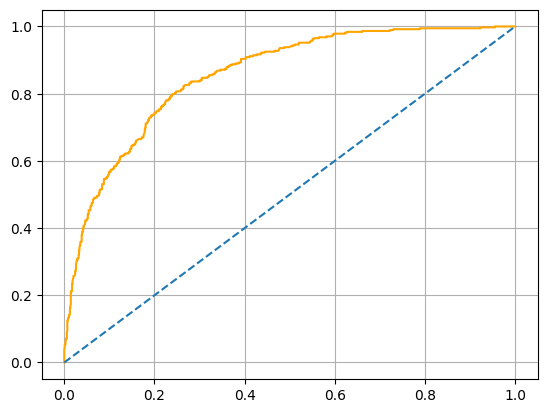

In [223]:
plt.plot(fpr, tpr, color = 'orange')
plt.plot([0,1],[0,1],linestyle='dashed')
plt.grid(True)

In [224]:
y_pred = (y_pred > best_threshold).astype(int)

In [225]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.80      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [229]:
confusion_matrix(y_test,y_pred)

array([[788, 248],
       [ 76, 297]])

<Axes: >

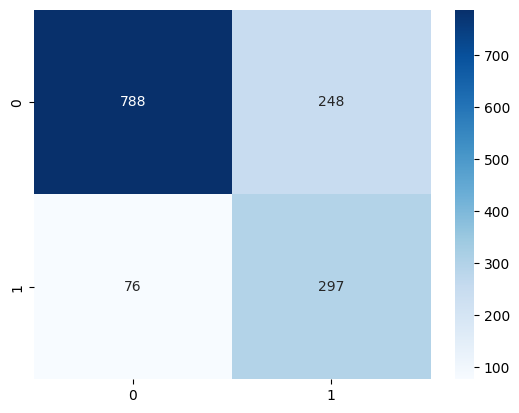

In [235]:
sns.heatmap(confusion_matrix(y_test,y_pred), cmap='Blues',annot=True, fmt='d')

In [236]:
import pickle

In [238]:
model_data = {
    'model' : final_model.best_estimator_,
    'threshold': threshold
}

In [239]:
with open('LoanPayBackXGBoost.pkl', 'wb') as f:
    pickle.dump(model_data, f)